In [17]:
##### Creates maps of agricultural capital and labor intensities 
# Side-by-side of pixel intensities and country intensities 

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer

In [18]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import data
capital_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/capital_intensity_USD_per_tonne.tif")
labor_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/labor_intensity_thousand_jobs_per_tonne.tif")

# National data
country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_boundaries = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/map_intensity_side_by_side"

In [19]:
### Data prep

# align rasters to capital grid
crs = capital_intensity.rio.crs

labor_intensity = labor_intensity.rio.reproject_match(capital_intensity)
country_boundaries = country_boundaries.to_crs(capital_intensity.rio.crs)

### Prep national intensities 

# merge to geo 
country_boundaries = country_boundaries.merge(country_codes, left_on='GID_0', right_on='SHP_code', how='left')
country_boundaries = country_boundaries.merge(country_intensities, on='ISO3', how='left')

country_boundaries['labor_intensity_thousand_jobs_per_tonne'] = country_boundaries['labor_intensity_jobs_per_tonne'] / 1e3

In [20]:
values = capital_intensity.values.flatten()

# drop NaNs (rasters typically have nodata pixels, e.g. ocean/non-agricultural areas)
values_clean = values[~np.isnan(values)]

# further restrict to values strictly above 0
values_clean = values_clean[values_clean > 0]

print(f"Total pixels: {len(values)}")
print(f"Valid (non-NaN, >0) pixels: {len(values_clean)}")

# pull every 10th percentile: 10, 20, 30, ..., 100
percentiles = np.arange(10, 101, 10)
percentile_values = np.percentile(values_clean, percentiles)

for p, v in zip(percentiles, percentile_values):
    print(f"{p}th percentile: {v:.2f}")

Total pixels: 9331200
Valid (non-NaN, >0) pixels: 1750227
10th percentile: 153.80
20th percentile: 286.92
30th percentile: 412.41
40th percentile: 574.62
50th percentile: 806.75
60th percentile: 1103.64
70th percentile: 1429.23
80th percentile: 1969.27
90th percentile: 2812.28
100th percentile: 357306.56


In [ ]:
##### Produce global map of capital intensity

# Prepare raster
value_plot = capital_intensity.squeeze()
name = 'capital_intensity'

bounds = [0, 1000, 2000, 3000, 4000, 5000] 
labels = ['0', '1', '2', '3', '4', '5+']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Country borders 
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=5000,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Capital Intensity", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("thousand USD per tonne", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

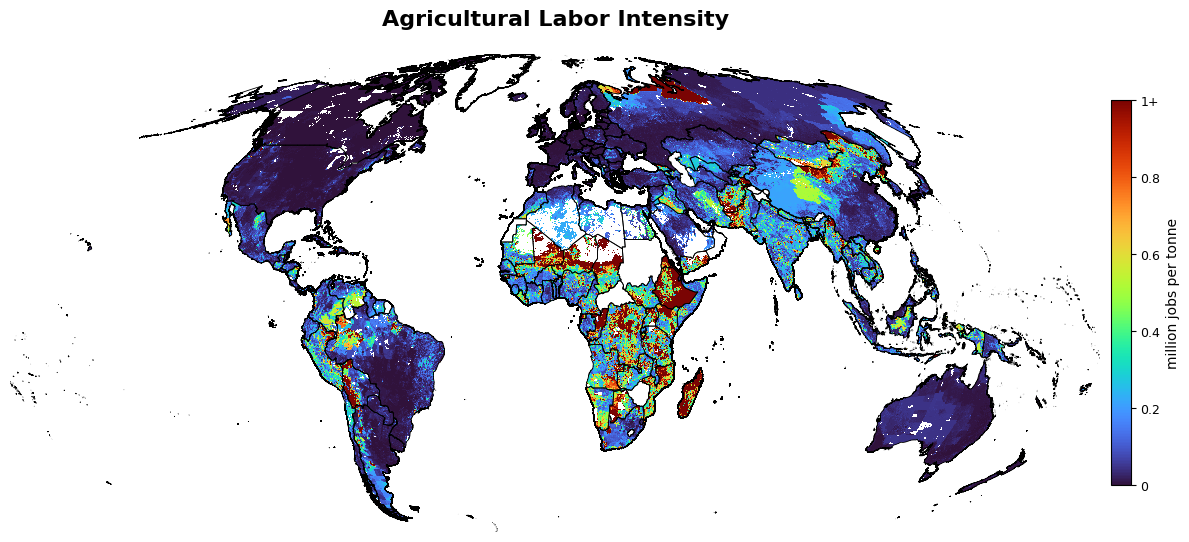

In [15]:
##### Produce global map of labor intensity

# Prepare raster
value_plot = labor_intensity.squeeze()
name = 'labor_intensity'

bounds = [0, 200, 400, 600, 800, 1000] 
labels = ['0', '0.2', '0.4', '0.6', '0.8', '1+']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Country borders 
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=1000,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Labor Intensity", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("million jobs per tonne", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')